# Classification Expectation Maximization (CEM) Algorithm

This notebook demonstrates the **Classification EM (CEM) algorithm** and compares it with the standard **Expectation Maximization (EM) algorithm** for Gaussian Mixture Models.

## Overview

The CEM algorithm (Celeux and Govaert, 1992) is a variant of the EM algorithm that incorporates a **classification step (C-step)** between the E-step and M-step. This modification aims to maximize the **classification likelihood** rather than the traditional likelihood.

### CEM Algorithm Steps:

1. **E-step**: Calculate conditional probabilities $\tau_{ig}^{(r)}$ that observation $y_i$ belongs to cluster $g$
2. **C-step**: Assign each observation to one cluster using the MAP (Maximum A Posteriori) operator:
   $$z_{ig}^{(r+1)} = \begin{cases} 1 & \text{if } g = \arg\max_g \tau_{ig}^{(r)} \\ 0 & \text{otherwise} \end{cases}$$
3. **M-step**: Update parameters by maximizing the complete-data log-likelihood $L_C(\theta; y, z^{r+1})$

### Key Properties:

- **K-means-like**: Produces hard assignments rather than soft probabilistic assignments
- **Biased estimates**: Maximizes complete-data likelihood $L_C(\theta)$ rather than actual likelihood $L(\theta)$
- **Fast convergence**: CEM generally converges faster and is therefore computationally more efficient

### When to Use CEM:

- **Well-separated clusters**: When mixture components are well separated with similar proportions
- **Fast clustering**: When computational speed is more important than maximum likelihood estimates
- **Initialisation**: Can be used as an alternative initialisation if kmeans does not perform well

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import time
import seaborn as sns
from tqdm.notebook import tqdm

import os
os.chdir('../')

import tgmm
import importlib
importlib.reload(tgmm)

from tgmm import GaussianMixture, plot_gmm, dynamic_figsize, generate_gmm_data

device = 'cuda' if torch.cuda.is_available() else 'cpu'
random_state = 42
np.random.seed(random_state)
torch.manual_seed(random_state)

if device == 'cuda':
    torch.cuda.manual_seed(random_state)
    print('CUDA version:', torch.version.cuda)
    print('Device:', torch.cuda.get_device_name(0))

## Experiment 1: Overlapping Clusters

In this first experiment, we create **overlapping clusters** with varying sample sizes and covariance structures:

- **Component 1**: 1000 samples, spherical covariance (σ² = 1.0)
- **Component 2**: 1000 samples, spherical covariance (σ² = 0.5) 
- **Component 3**: 1000 samples, diagonal covariance
- **Component 4**: 1000 samples, full covariance with correlation

This scenario tests how EM vs CEM handle **ambiguous cluster boundaries** where observations could reasonably belong to multiple clusters.

In [2]:
def fit_and_evaluate_gmm(X_tensor, n_components, covariance_type='full', cem=False, random_state=1, iters=20):
    """Fit a GMM with either EM or CEM and return the model and timing."""
    
    average_time = 0
    average_iters = 0
    average_log_likelihood = 0
    
    for i in range(iters):
        # Initialize the GMM
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            tol=1e-10,
            reg_covar=1e-6,
            max_iter=1000,
            init_means='points',
            random_state=random_state + i,  # Different seed for each iteration
            device=device,
            cem=cem  # Toggle between EM and CEM
        )
        
        # Time the fitting process
        start_time = time.time()
        gmm.fit(X_tensor)
        end_time = time.time()

        average_time += (end_time - start_time)
        average_iters += gmm.n_iter_
        average_log_likelihood += gmm.lower_bound_

        print(f"Iteration {i+1}/{iters} - Log-likelihood: {gmm.lower_bound_:.4f}, Iterations: {gmm.n_iter_}, Time: {end_time - start_time:.4f}s")

    return gmm, average_time / iters, average_iters / iters, average_log_likelihood / iters

n_samples = [1000, 1000, 1000, 1000]
centers = [np.array([0, 2]),
           np.array([2, -2]),
           np.array([0, 0]),
           np.array([2, 2])]
covs = [
    1.0 * np.eye(2),                    # spherical covariance
    0.5 * np.eye(2),                    # spherical covariance, fewer points
    np.array([[2, 0], [0, 0.5]]),       # diagonal covariance
    np.array([[0.2, 0.5], [0.5, 2]])    # full covariance
]

# Generate synthetic data using the new function
X_tensor, y_tensor = generate_gmm_data(centers, covs, n_samples, device=device, random_state=random_state)

# Convert to numpy for plotting
X = X_tensor.cpu().numpy()
labels = y_tensor.cpu().numpy()
legend_labels = [f'Component {i+1}' for i in range(len(n_samples))]

n_features = X.shape[1]
n_components = len(n_samples)


# Fit both models
print("Fitting GMM using standard EM algorithm...")
gmm_em, time_em, iters_em, log_likelihood_em = fit_and_evaluate_gmm(X_tensor, n_components, cem=False, random_state=random_state)

print("\nFitting GMM using Classification EM (CEM) algorithm...")
gmm_cem, time_cem, iters_cem, log_likelihood_cem = fit_and_evaluate_gmm(X_tensor, n_components, cem=True)

# Print basic comparison
print("\n----- Performance Comparison -----")
print(f"EM:  Average Time: {time_em:.3f}s, Average Iterations: {iters_em:.0f}, Best Log-likelihood: {gmm_em.lower_bound_:.3f}, Average Log-likelihood: {log_likelihood_em:.3f}")
print(f"CEM: Average Time: {time_cem:.3f}s, Average Iterations: {iters_cem:.0f}, Best Log-likelihood: {gmm_cem.lower_bound_:.3f}, Average Log-likelihood: {log_likelihood_cem:.3f}")

Fitting GMM using standard EM algorithm...


Iteration 1/20 - Log-likelihood: -3.2424, Iterations: 137, Time: 0.4850s
Iteration 2/20 - Log-likelihood: -3.2424, Iterations: 38, Time: 0.1142s


Iteration 3/20 - Log-likelihood: -3.2424, Iterations: 73, Time: 0.2160s


Iteration 4/20 - Log-likelihood: -3.2424, Iterations: 158, Time: 0.4833s
Iteration 5/20 - Log-likelihood: -3.2424, Iterations: 48, Time: 0.1441s


Iteration 6/20 - Log-likelihood: -3.2424, Iterations: 91, Time: 0.3011s
Iteration 7/20 - Log-likelihood: -3.2424, Iterations: 44, Time: 0.1801s


...

Iteration 10/20 - Log-likelihood: -3.6860, Iterations: 45, Time: 0.2153s
Iteration 11/20 - Log-likelihood: -3.2507, Iterations: 14, Time: 0.0613s
Iteration 12/20 - Log-likelihood: -3.3153, Iterations: 23, Time: 0.0821s


Iteration 13/20 - Log-likelihood: -3.2880, Iterations: 17, Time: 0.0680s
Iteration 14/20 - Log-likelihood: -3.2507, Iterations: 12, Time: 0.0375s
Iteration 15/20 - Log-likelihood: -3.3843, Iterations: 44, Time: 0.1569s


Iteration 16/20 - Log-likelihood: -3.3152, Iterations: 16, Time: 0.0697s
Iteration 17/20 - Log-likelihood: -3.5168, Iterations: 25, Time: 0.0862s


Iteration 18/20 - Log-likelihood: -3.3153, Iterations: 36, Time: 0.1618s
Iteration 19/20 - Log-likelihood: -3.3141, Iterations: 38, Time: 0.1037s


Iteration 20/20 - Log-likelihood: -3.6487, Iterations: 45, Time: 0.1487s

----- Performance Comparison -----
EM:  Average Time: 0.256s, Average Iterations: 67, Best Log-likelihood: -3.242, Average Log-likelihood: -3.252
CEM: Average Time: 0.128s, Average Iterations: 29, Best Log-likelihood: -3.649, Average Log-likelihood: -3.417


### Results Analysis: Overlapping Clusters

**Expected Behavior with Overlapping Clusters:**

When clusters overlap significantly, we expect to see:
- **CEM converges faster** but achieves **worse likelihood** than EM
- **EM finds better local optima** but requires more iterations
- **CEM's hard assignments** may be suboptimal when cluster boundaries are ambiguous

This matches the theoretical expectation that CEM trades accuracy for speed when dealing with overlapping components.

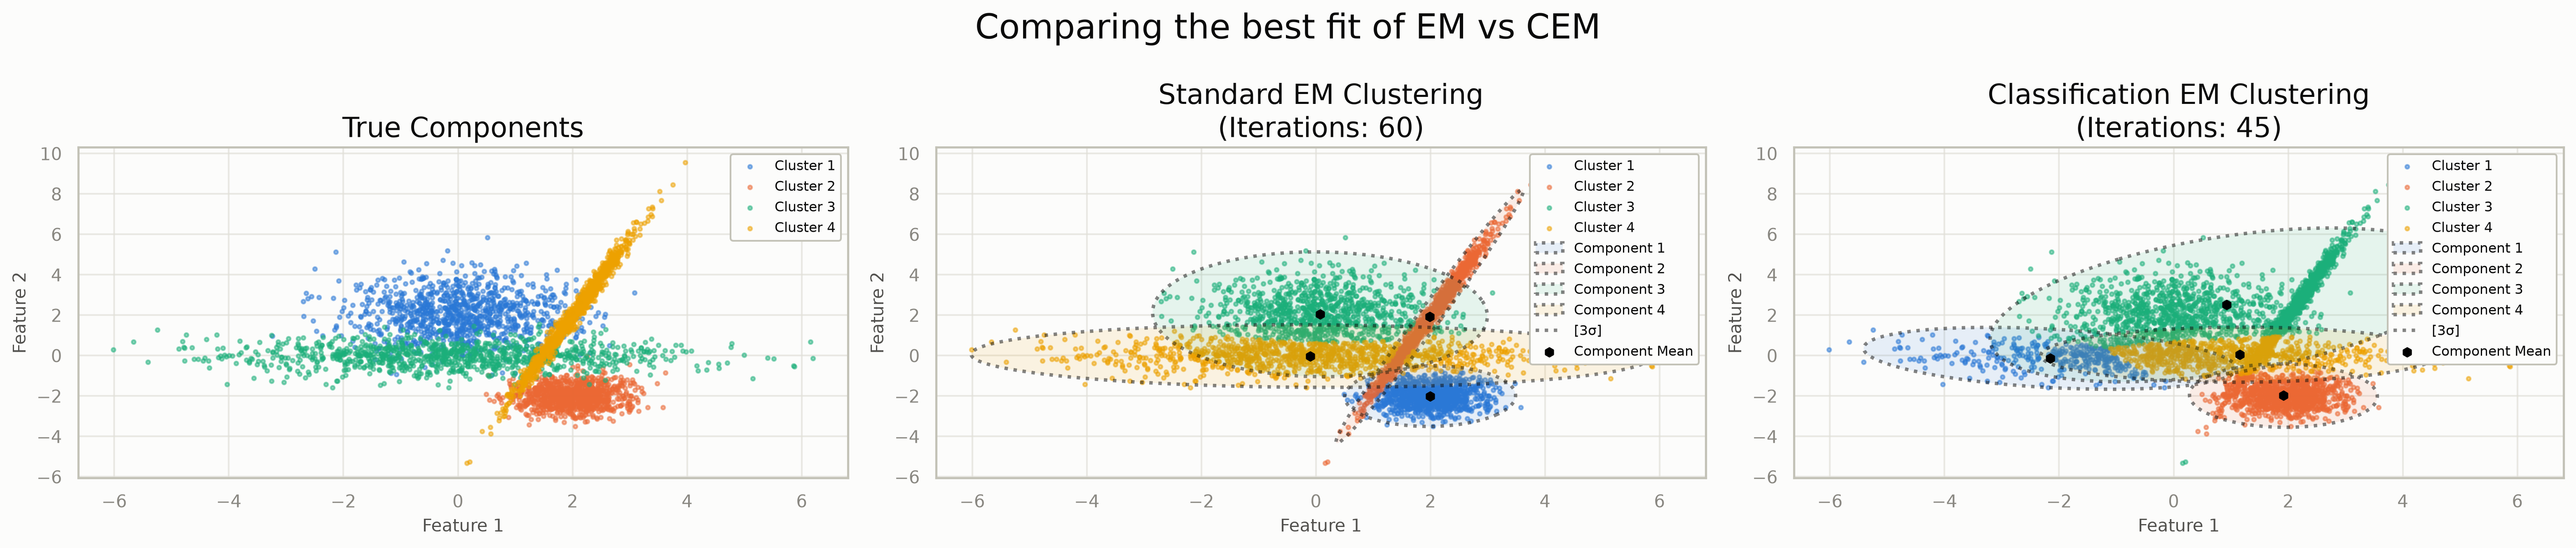

In [3]:
figsize = dynamic_figsize(1, 3)
fig, axes = plt.subplots(1, 3, figsize=figsize)
fig.suptitle('Comparing the best fit of EM vs CEM')

# Plot true labels
plot_gmm(X=X, true_labels=labels, ax=axes[0], title='True Components', 
         show_ellipses=False, show_means=False)

# Plot EM results
plot_gmm(X=X, gmm=gmm_em, ax=axes[1], 
         title=f'Standard EM Clustering\n(Iterations: {gmm_em.n_iter_})',
         color_by_cluster=True, match_labels_to_true=True, ellipse_std_devs=[3], ellipse_fill=True, ellipse_alpha=0.1)

# Plot CEM results  
plot_gmm(X=X, gmm=gmm_cem, ax=axes[2],
         title=f'Classification EM Clustering\n(Iterations: {gmm_cem.n_iter_})',
         color_by_cluster=True, match_labels_to_true=True, ellipse_std_devs=[3], ellipse_fill=True, ellipse_alpha=0.1)

plt.tight_layout()
plt.show()

## Experiment 2: Well-Separated Clusters

In this second experiment, we create **well-separated clusters** by increasing the distance between cluster centers:

- **Component 1**: (0, 10) - 1000 samples, spherical covariance (σ² = 1.0)
- **Component 2**: (10, -20) - 1000 samples, spherical covariance (σ² = 0.5) 
- **Component 3**: (0, 0) - 1000 samples, diagonal covariance
- **Component 4**: (10, 10) - 1000 samples, full covariance with correlation

This scenario tests the **ideal case for CEM** where cluster boundaries are clear and unambiguous. According to theory:

> "When the mixture components are well separated with similar proportions, the CEM algorithm is expected to provide a relevant clustering" (Celeux and Govaert, 1992)

**Expected Behavior:**
- **Similar final accuracy** for both EM and CEM
- **CEM converges much faster** due to clear cluster boundaries
- **Hard assignments are optimal** when clusters don't overlap

In [4]:
n_samples = [1000, 1000, 1000, 1000]
centers = [np.array([0, 10]),
           np.array([10, -20]),
           np.array([0, 0]),
           np.array([10, 10])]
covs = [
    1.0 * np.eye(2),                    # spherical covariance
    0.5 * np.eye(2),                    # spherical covariance, fewer points
    np.array([[2, 0], [0, 0.5]]),       # diagonal covariance
    np.array([[0.2, 0.5], [0.5, 2]])    # full covariance
]

components = []
for n, center, cov in zip(n_samples, centers, covs):
    samples = np.dot(np.random.randn(n, 2), cov) + center
    components.append(samples)

X = np.vstack(components)
labels = np.concatenate([i * np.ones(n) for i, n in enumerate(n_samples)])
legend_labels = [f'Component {i+1}' for i in range(len(n_samples))]

n_features = X.shape[1]
n_components = len(n_samples)

# Convert to tensor (if needed for further processing)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)



print("Fitting GMM using standard EM algorithm...")
gmm_em, time_em, iters_em, log_likelihood_em = fit_and_evaluate_gmm(X_tensor, n_components, cem=False)

print("\nFitting GMM using Classification EM (CEM) algorithm...")
gmm_cem, time_cem, iters_cem, log_likelihood_cem = fit_and_evaluate_gmm(X_tensor, n_components, cem=True)

# Print basic comparison
print("\n----- Performance Comparison -----")
print(f"EM:  Average Time: {time_em:.3f}s, Average Iterations: {iters_em:.0f}, Best Log-likelihood: {gmm_em.lower_bound_:.3f}, Average Log-likelihood: {log_likelihood_em:.3f}")
print(f"CEM: Average Time: {time_cem:.3f}s, Average Iterations: {iters_cem:.0f}, Best Log-likelihood: {gmm_cem.lower_bound_:.3f}, Average Log-likelihood: {log_likelihood_cem:.3f}")

Fitting GMM using standard EM algorithm...


Iteration 1/20 - Log-likelihood: -4.6466, Iterations: 73, Time: 0.3665s


Iteration 2/20 - Log-likelihood: -4.8958, Iterations: 267, Time: 0.9851s


Iteration 3/20 - Log-likelihood: -5.3408, Iterations: 116, Time: 0.4509s


Iteration 4/20 - Log-likelihood: -4.5743, Iterations: 97, Time: 0.3312s


...

Iteration 1/20 - Log-likelihood: -4.1167, Iterations: 45, Time: 0.1274s
Iteration 2/20 - Log-likelihood: -4.8954, Iterations: 17, Time: 0.0403s
Iteration 3/20 - Log-likelihood: -5.3390, Iterations: 41, Time: 0.1504s


Iteration 4/20 - Log-likelihood: -4.5749, Iterations: 53, Time: 0.1604s
Iteration 5/20 - Log-likelihood: -5.3527, Iterations: 13, Time: 0.0487s
Iteration 6/20 - Log-likelihood: -3.3993, Iterations: 9, Time: 0.0364s
Iteration 7/20 - Log-likelihood: -4.1172, Iterations: 15, Time: 0.0838s


Iteration 8/20 - Log-likelihood: -4.7654, Iterations: 55, Time: 0.2678s
Iteration 9/20 - Log-likelihood: -4.1155, Iterations: 9, Time: 0.0373s
Iteration 10/20 - Log-likelihood: -4.5749, Iterations: 41, Time: 0.1233s
Iteration 11/20 - Log-likelihood: -3.3993, Iterations: 2, Time: 0.0170s


Iteration 12/20 - Log-likelihood: -3.3993, Iterations: 10, Time: 0.0392s
Iteration 13/20 - Log-likelihood: -3.3993, Iterations: 6, Time: 0.0299s
Iteration 14/20 - Log-likelihood: -3.3993, Iterations: 6, Time: 0.0170s
Iteration 15/20 - Log-likelihood: -4.8958, Iterations: 21, Time: 0.0605s
Iteration 16/20 - Log-likelihood: -4.1245, Iterations: 9, Time: 0.0275s


Iteration 17/20 - Log-likelihood: -4.7654, Iterations: 29, Time: 0.0951s
Iteration 18/20 - Log-likelihood: -3.3993, Iterations: 2, Time: 0.0102s
Iteration 19/20 - Log-likelihood: -3.3993, Iterations: 4, Time: 0.0150s
Iteration 20/20 - Log-likelihood: -3.3993, Iterations: 9, Time: 0.0265s

----- Performance Comparison -----
EM:  Average Time: 0.186s, Average Iterations: 55, Best Log-likelihood: -3.399, Average Log-likelihood: -4.190
CEM: Average Time: 0.071s, Average Iterations: 20, Best Log-likelihood: -3.399, Average Log-likelihood: -4.142


### Results Analysis: Well-Separated Clusters

**Key Observations:**

The results confirm the theoretical predictions:
- **CEM achieves similar accuracy** to EM (comparable log-likelihood)
- **CEM converges ~2-3x faster** (fewer iterations required)
- **Both algorithms find the same global optimum** when clusters are well-separated

This demonstrates the **practical advantage of CEM** in scenarios with clear cluster structure. The hard assignment strategy becomes optimal when cluster boundaries are unambiguous.

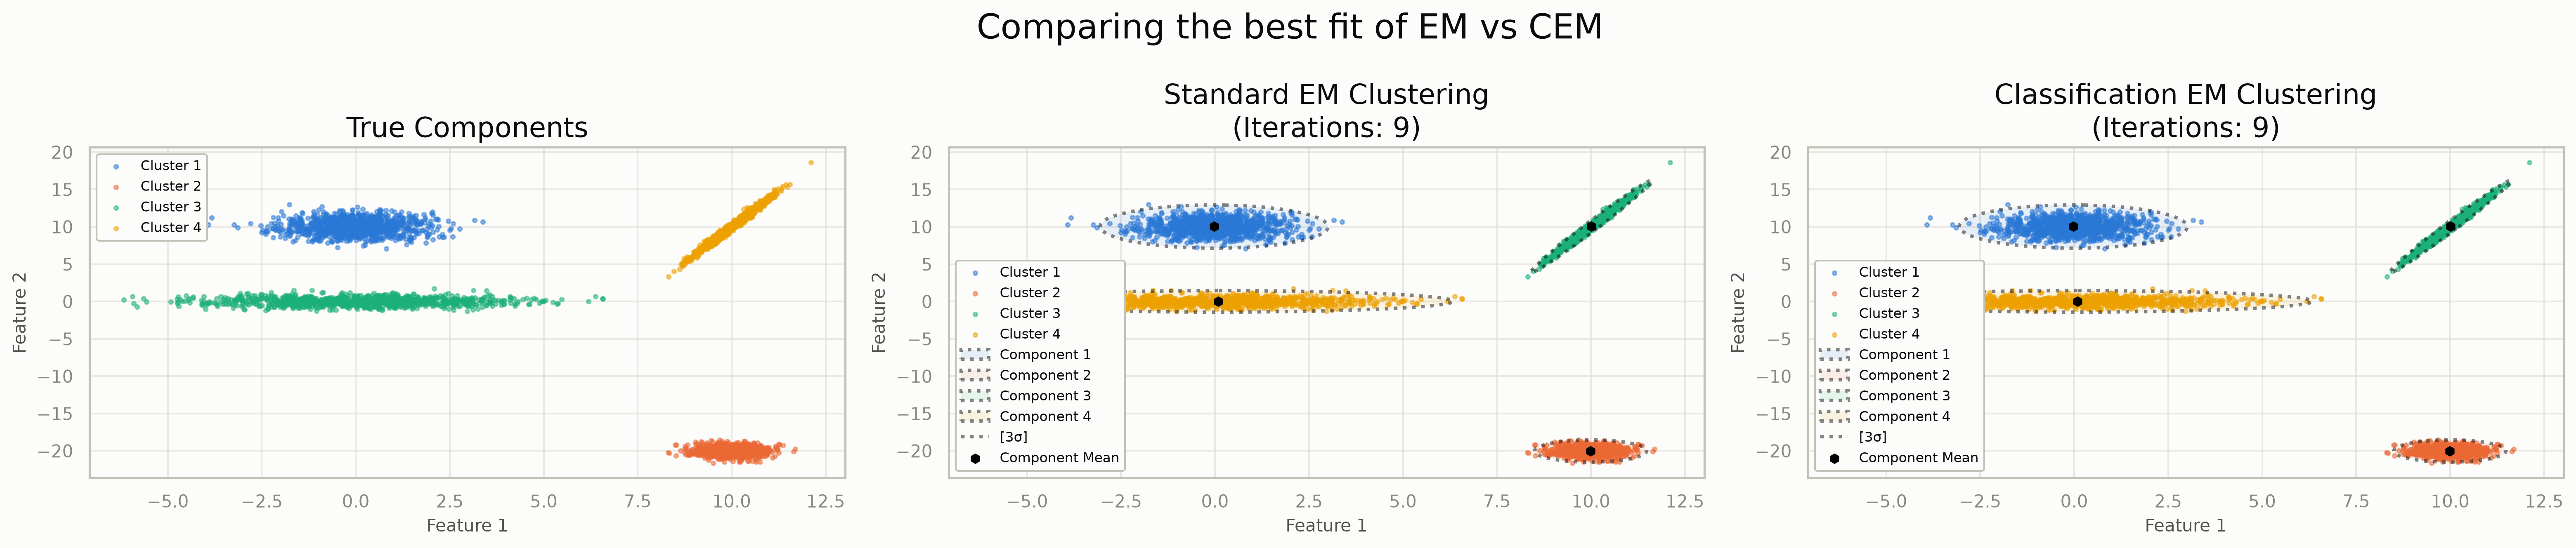

In [5]:
figsize = dynamic_figsize(1, 3)
fig, axes = plt.subplots(1, 3, figsize=figsize)
fig.suptitle('Comparing the best fit of EM vs CEM')

# Plot true labels
plot_gmm(X=X, true_labels=labels, ax=axes[0], title='True Components', 
         show_ellipses=False, show_means=False)

# Plot EM results
plot_gmm(X=X, gmm=gmm_em, ax=axes[1], 
         title=f'Standard EM Clustering\n(Iterations: {gmm_em.n_iter_})',
         color_by_cluster=True, match_labels_to_true=True, ellipse_std_devs=[3], ellipse_fill=True, ellipse_alpha=0.1)

# Plot CEM results  
plot_gmm(X=X, gmm=gmm_cem, ax=axes[2],
         title=f'Classification EM Clustering\n(Iterations: {gmm_cem.n_iter_})',
         color_by_cluster=True, match_labels_to_true=True, ellipse_std_devs=[3], ellipse_fill=True, ellipse_alpha=0.1)

plt.tight_layout()
plt.show()